In [23]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import salem
import pandas as pd
import numpy as np
plt.style.use('bmh')
from scipy.stats import spearmanr
import os
import glob

In [58]:
plotdir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures/'

In [67]:
clim_dir = '/home/chc-shrad/DATA/SIF/climatology/fusion_SCIAMACHY_GOME-2'
CROP_MASK_PATH = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/crop_mask_fraction_on_sif_grid_conservative.nc'
crop_data = pd.read_csv('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_africa_data_v1.0_20250212.csv')
chirps = pd.read_hdf('/home/cape/CAPE/data_chirps3/data2/data_processed/prcp_chirps-v3.all.hdf')

In [5]:
## Reading SIF data and shape file
date_range = pd.date_range(start='2003-01-01', end='2017-12-31', freq='ME')
crop_mask = xr.open_dataset(CROP_MASK_PATH)
admin_shp = gpd.read_file('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_boundary.gpkg')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range

In [68]:
admin_correlation_results = []
for admin_name in admin_shp[admin_shp['ADMIN0']=='South Africa']['ADMIN1'].unique()[1:]:
    shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
    sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
    crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
    sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
    sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
    sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)
    aggregated_sif = sif_yearly_max_masked.sum(dim=['lon', 'lat'])
    crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
    sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
    aggregated_sif = aggregated_sif.sel(year=aggregated_sif.year.isin(sel_crop_data_admin['harvest_year']))
    correlation_sif, p_value_sif = spearmanr(aggregated_sif.values, sel_crop_data_admin['yield'].values)

    accumulated_chirps = chirps[shdf['FNID']].resample('ME').sum().rolling(window=6, center=False).sum()
    yearly_chirps = accumulated_chirps[(accumulated_chirps.index.month==3) & (accumulated_chirps.index.year>=2003) & (accumulated_chirps.index.year<=2017)]
    yearly_chirps.index = yearly_chirps.index.year

    yearly_chirps = yearly_chirps[yearly_chirps.index.isin(sel_crop_data_admin['harvest_year'])]
    correlation_chirps, p_value_chirps = spearmanr(yearly_chirps.values, sel_crop_data_admin['yield'].values)


    admin_correlation_results.append({'ADMIN_1': admin_name, 'correlation_sif': correlation_sif, 'p_value_sif': p_value_sif,
                                      'correlation_chirps': correlation_chirps, 'p_value_chirps': p_value_chirps})
admin_yield_SIF_correlation_df = pd.DataFrame(admin_correlation_results)

In [69]:
## masking crop mask for entire country
admin_names = admin_shp[admin_shp['ADMIN0']=='South Africa']['ADMIN1'].unique()[1:]
shdf = admin_shp[admin_shp['ADMIN1'].isin(admin_names)]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)

Saving figure to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures//SIF_yield_correlation_map.png


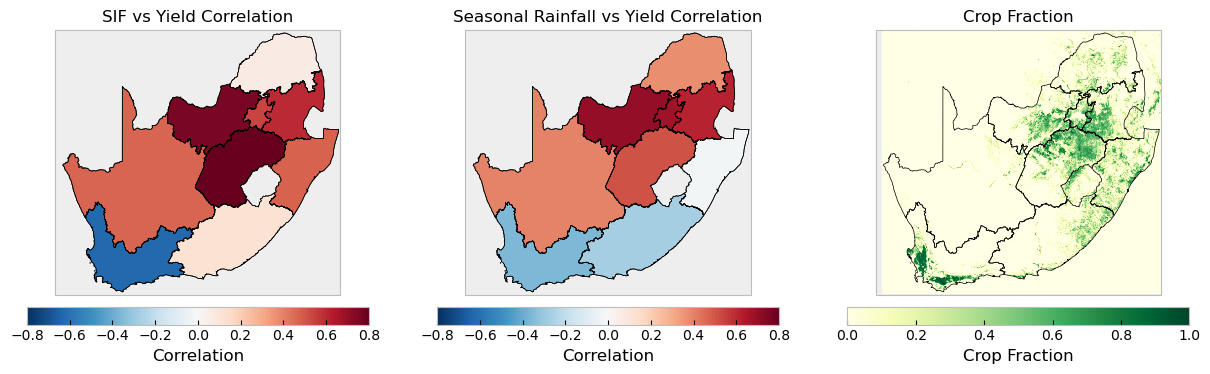

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'RdBu_r'
axes = axes.flatten()
axes[0].set_extent([16, 33, -35, -22])
axes[0].set_title('SIF vs Yield Correlation', fontsize=12)
merge_gpd = pd.merge(admin_yield_SIF_correlation_df, admin_shp[['ADMIN1', 'geometry']], left_on='ADMIN_1', right_on='ADMIN1')
merge_gpd = gpd.GeoDataFrame(merge_gpd, geometry='geometry', crs=admin_shp.crs)
merge_gpd.plot(ax=axes[0], column='correlation_sif', cmap=cmap, vmin=-0.8, vmax=0.8, legend=False, edgecolor='black')
shdf.plot(ax=axes[0], facecolor='none', edgecolor='black')

cs = fig.colorbar(axes[0].collections[0], ax=axes[0], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Correlation', fontsize=12)

axes[1].set_extent([16, 33, -35, -22])
axes[1].set_title('Seasonal Rainfall vs Yield Correlation', fontsize=12)
merge_gpd = pd.merge(admin_yield_SIF_correlation_df, admin_shp[['ADMIN1', 'geometry']], left_on='ADMIN_1', right_on='ADMIN1')
merge_gpd = gpd.GeoDataFrame(merge_gpd, geometry='geometry', crs=admin_shp.crs)
merge_gpd.plot(ax=axes[1], column='correlation_chirps', cmap=cmap, vmin=-0.8, vmax=0.8, legend=False, edgecolor='black')
shdf.plot(ax=axes[1], facecolor='none', edgecolor='black')

cs = fig.colorbar(axes[1].collections[0], ax=axes[1], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Correlation', fontsize=12)

axes[2].set_extent([16, 33, -35, -22])

crop_mask_sub['crop_fraction'].plot(ax=axes[2], cmap='YlGn', vmin=0, vmax=1, add_colorbar=False)
shdf.plot(ax=axes[2], facecolor='none', edgecolor='black')
axes[2].set_title('Crop Fraction', fontsize=12)

cs = fig.colorbar(axes[2].collections[0], ax=axes[2], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Crop Fraction', fontsize=12)

Figure = f'{plotdir}/SIF_yield_correlation_map.png'
print (f'Saving figure to {Figure}')
plt.savefig(Figure, dpi=300, bbox_inches='tight')

Saving figure to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures//SIF_vs_Yield_in_Free_State.png


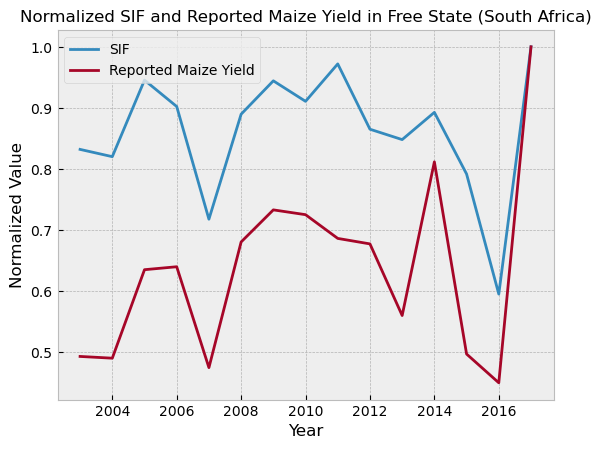

In [74]:
admin_name = 'Free State'
shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)
aggregated_sif = sif_yearly_max_masked.sum(dim=['lon', 'lat'])
crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
aggregated_sif = aggregated_sif.sel(year=aggregated_sif.year.isin(sel_crop_data_admin['harvest_year']))

plt.plot(aggregated_sif.year, aggregated_sif.values/aggregated_sif.values.max(), label='SIF')
plt.plot(sel_crop_data_admin['harvest_year'], sel_crop_data_admin['yield']/sel_crop_data_admin['yield'].max(), label='Reported Maize Yield')
plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.title('Normalized SIF and Reported Maize Yield in Free State (South Africa)', fontsize=12)
plt.legend()

Figure = f'{plotdir}/SIF_vs_Yield_in_Free_State.png'
print (f'Saving figure to {Figure}')
plt.savefig(Figure, dpi=300, bbox_inches='tight')

Saving figure to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures//comparison_of_downscaled_yield_maps_for_free_state.png


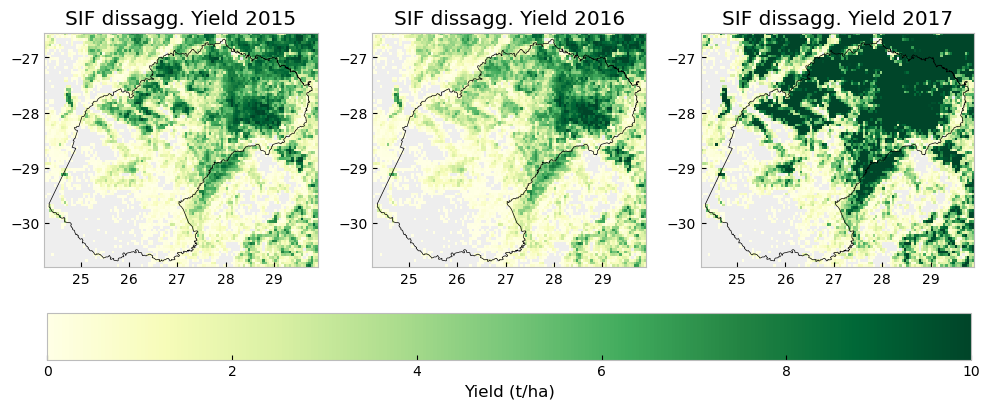

In [84]:
## Calculating SIF weights and downscaling yield

admin_name = 'Free State'
shdf = admin_shp[admin_shp['ADMIN1']==admin_name]
sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)
sif_yearly_max = sif_rt_sub.sel(time=sif_rt_sub['time.month'].isin([1,2,3])).groupby('time.year').max(dim='time')
sif_yearly_max_masked = sif_yearly_max['SIF_740_daily_corr']*crop_mask_sub['crop_fraction']
sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)

## selecting crop yield data for the specific admin region
crop_data_admin = crop_data[crop_data['admin_1']==admin_name]
sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']=='Maize') & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['harvest_year', 'yield']]
# Creating a DataArray for yield data with the same time dimension as the SIF data
yield_da = xr.DataArray(
    sel_crop_data_admin['yield'].values,
    coords={'year': sif_yearly_max_masked.year.values},
    dims=['year']
)

sif_weight = sif_yearly_max_masked / sif_yearly_max_masked.max(dim=['lon', 'lat'])
# --- Approach 2: Sum-normalized weights (spatial mean == admin yield) ---
# Normalise so weights sum to 1, then rescale by number of valid pixels → mean preserved
n_pixels = sif_weight.count(dim=['lon', 'lat'])
sif_weight_norm = (sif_weight / sif_weight.sum(dim=['lon', 'lat'])) * n_pixels
downscaled_yield_conserved = sif_weight_norm * yield_da

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for cnt, year, in enumerate([2015, 2016, 2017]):
    ax= axes[cnt]
    downscaled_yield_conserved.sel(year=year).plot(ax=axes[cnt], cmap='YlGn', vmin=0, vmax=10, add_colorbar=False)
    ax.set_title('SIF dissagg. Yield {}'.format(year))
    shdf.plot(ax=ax, facecolor='none', edgecolor='black')
    ax.set_xlabel('')
    ax.set_ylabel('')

cs = fig.colorbar(axes[0].collections[0], ax=axes, orientation='horizontal', fraction=0.1, pad=0.1); cs.set_label('Yield (t/ha)', fontsize=12)

downscaled_yield_mean = downscaled_yield_conserved.mean(dim='year')
downscaled_yield_std = downscaled_yield_conserved.std(dim='year')



Figure = f'{plotdir}/comparison_of_downscaled_yield_maps_for_free_state.png'
print (f'Saving figure to {Figure}')
plt.savefig(Figure, dpi=300, bbox_inches='tight')


In [60]:
## Reading SIF data and shape file
date_range = pd.date_range(start='2003-01-01', end='2017-12-31', freq='ME')
crop_mask = xr.open_dataset(CROP_MASK_PATH)
admin_shp = gpd.read_file('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/Harvest_stat/hvstat_boundary.gpkg')
sif_data = xr.open_mfdataset(f'/home/chc-shrad/DATA/SIF/fusion_SCIAMACHY_GOME-2/SIF_SCIAMACHY_GOME2_Harmonized.*_subsetted.nc4', 
                             concat_dim='time', combine='nested')
sif_data.coords['time'] = date_range

In [61]:
## Downscaling yield using SIF data
country, crop_type, crop_production_system, season_name, admin_type = 'South Africa', 'Maize', 'Commercial (PS)', 'Summer', 'ADMIN1'

for admin_name in admin_shp[admin_shp['ADMIN0']==country][admin_type].unique()[1:]:
    fnid = admin_shp[admin_shp[admin_type]==admin_name]['FNID'].values[0]
    # Extracting SIF and crop mask data for the specific admin region
    shdf = admin_shp[admin_shp[admin_type]==admin_name]
    sif_rt_sub = sif_data.salem.subset(shape=shdf, margin=2)
    crop_mask_sub = crop_mask.salem.subset(shape=shdf, margin=2)

    ## selecting crop yield data for the specific admin region and crop type
    if admin_type.lower() == 'admin1':
        crop_admin_type = 'admin_1'
    elif admin_type.lower() == 'admin2':
        crop_admin_type = 'admin_2'
    elif admin_type.lower() == 'admin3':
        crop_admin_type = 'admin_3'

    crop_data_admin = crop_data[crop_data[crop_admin_type]==admin_name]
    sel_crop_data_admin = crop_data_admin[(crop_data_admin['product']==crop_type) & (crop_data_admin['harvest_year'].isin(np.arange(2003, 2018)))][['planting_year', 'planting_month', 'harvest_year', 'harvest_month', 'yield']]
    
    # Inspect season table (already prepared)
    sel_crop_data_admin = sel_crop_data_admin.sort_values('harvest_year').reset_index(drop=True)

    # Build seasonal SIF max using planting/harvest timing from each row
    seasonal_max_list = []

    for _, row in sel_crop_data_admin.iterrows():
        p_year = int(row['planting_year'])
        p_month = int(row['planting_month'])
        h_year = int(row['harvest_year'])
        h_month = int(row['harvest_month'])

        # Season window: from first day of planting month to end of harvest month
        season_start = pd.Timestamp(p_year, p_month, 1)
        season_end = pd.Timestamp(h_year, h_month, 1) + pd.offsets.MonthEnd(1)

        sif_season = sif_rt_sub.sel(time=slice(season_start, season_end))['SIF_740_daily_corr']

        if sif_season.sizes.get('time', 0) > 0:
            season_max = sif_season.max(dim='time', skipna=True)
        else:
            season_max = sif_rt_sub['SIF_740_daily_corr'].isel(time=0) * np.nan

        season_max = season_max.expand_dims(year=[h_year])
        seasonal_max_list.append(season_max)

    # Final DataArray: (year, lat, lon) with one max map per growing season year
    sif_yearly_max = xr.concat(seasonal_max_list, dim='year')

    sif_yearly_max_masked = sif_yearly_max*crop_mask_sub['crop_fraction']
    sif_yearly_max_masked = sif_yearly_max_masked.where(sif_yearly_max_masked>0, other=np.nan)

    # Creating a DataArray for yield data with the same time dimension as the SIF data
    yield_da = xr.DataArray(
            sel_crop_data_admin['yield'].values,
            coords={'year': sif_yearly_max_masked.year.values},
            dims=['year']
        )

    sif_weight = sif_yearly_max_masked / sif_yearly_max_masked.max(dim=['lon', 'lat'])

    # Normalise so weights sum to 1, then rescale by number of valid pixels → mean preserved
    n_pixels = sif_weight.count(dim=['lon', 'lat'])
    sif_weight_norm = (sif_weight / sif_weight.sum(dim=['lon', 'lat'])) * n_pixels
    downscaled_yield_conserved = sif_weight_norm * yield_da

    outdir = '/home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based'
    os.makedirs(outdir, exist_ok=True)
    outfile = f'{outdir}/downscaled_yield_fnid_{fnid}_{country.replace(" ", "_")}_{admin_name.replace(" ", "_")}.nc'
    print (f'Saving downscaled yield for {admin_name} to {outfile}')
    downscaled_yield_conserved.to_dataset(name='SIF_yield').to_netcdf(outfile)


Saving downscaled yield for Western Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A101_South_Africa_Western_Cape.nc
Saving downscaled yield for Eastern Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A102_South_Africa_Eastern_Cape.nc
Saving downscaled yield for Northern Cape to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A103_South_Africa_Northern_Cape.nc


/home/shrad/miniforge3/envs/py312/lib/python3.12/site-packages/dask/array/reductions.py:654: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


Saving downscaled yield for Free State to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A104_South_Africa_Free_State.nc
Saving downscaled yield for Kwazulu-Natal to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A105_South_Africa_Kwazulu-Natal.nc
Saving downscaled yield for North West to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A106_South_Africa_North_West.nc
Saving downscaled yield for Gauteng to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A107_South_Africa_Gauteng.nc
Saving downscaled yield for Mpumalanga to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_ZA1994A108_South_Africa_Mpumalanga.nc
Saving downscaled yield for Limpopo to /home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downsca

In [38]:
spam_all = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/SPAM/spam2020V2r2_global_yield/spam2020_V2r2_global_Y_MAIZ_A.tif')
spam_rainfed = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/SPAM/spam2020V2r2_global_yield/spam2020_V2r2_global_Y_MAIZ_R.tif')
spam_irrigated = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_yield_reports/SPAM/spam2020V2r2_global_yield/spam2020_V2r2_global_Y_MAIZ_I.tif')

Saving figure to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/figures//SPAM_2020_vs_SIF_disaggregated_yield_comparison_for_South_Africa.png


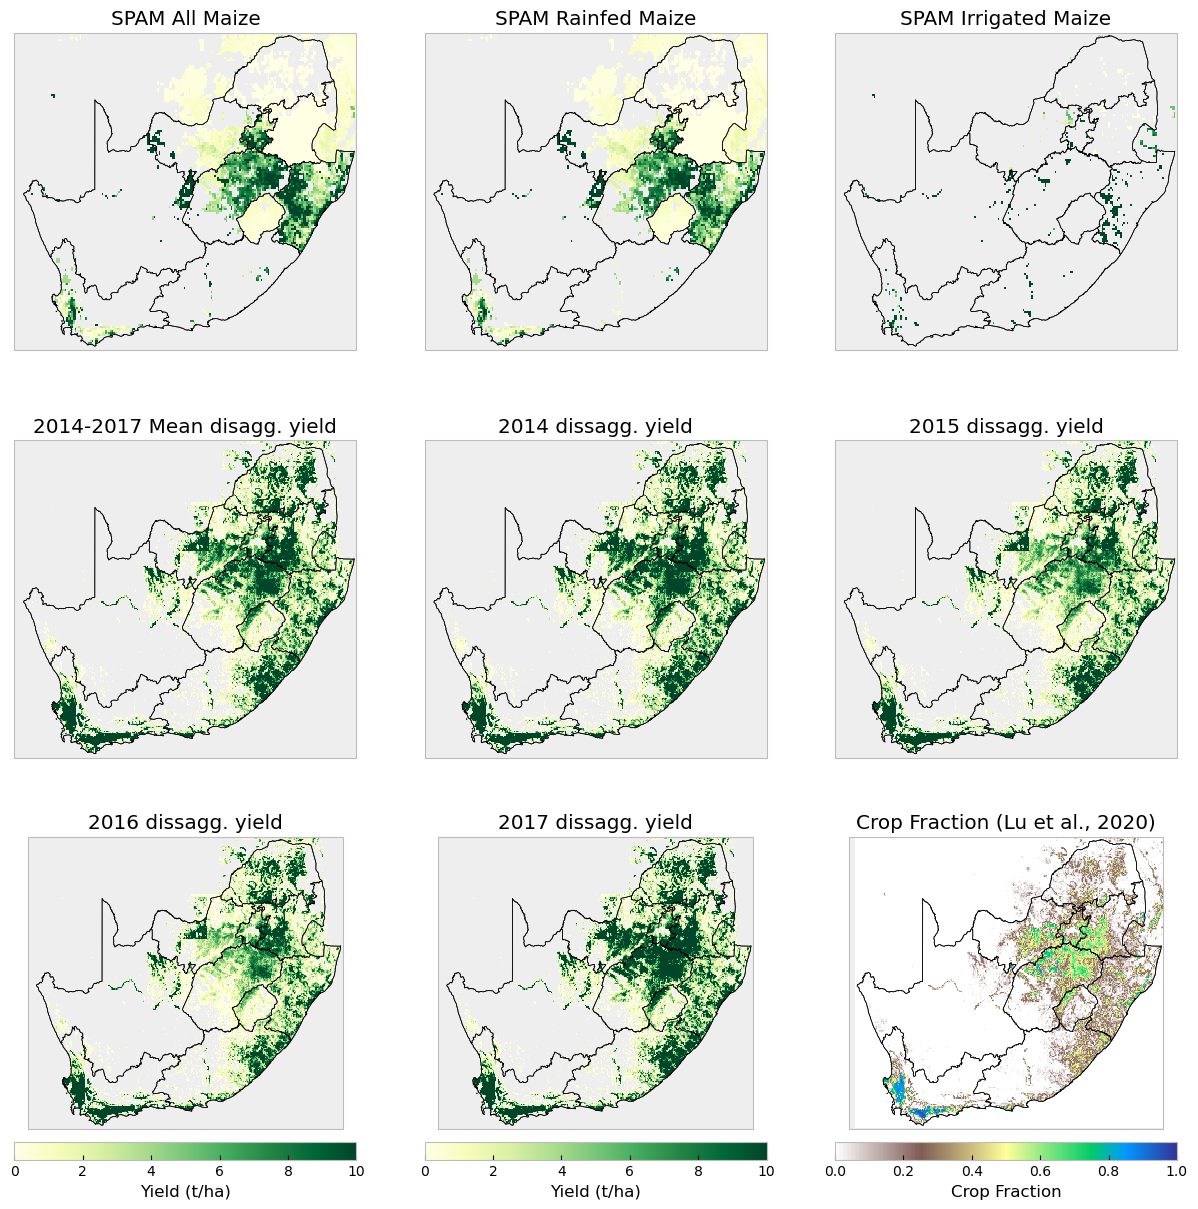

In [59]:
## Calculating SIF weights and downscaling yield

shdf = admin_shp[admin_shp['ADMIN0']=='South Africa']


fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for count, (spam_data, title) in enumerate(zip([spam_all, spam_rainfed, spam_irrigated], ['All Maize', 'Rainfed Maize', 'Irrigated Maize'])):
    ax = axes[count]
    ax.set_extent([16, 33, -35, -22])
    crop_spam = spam_data.salem.subset(shape=shdf, margin=2)
    (crop_spam['band_data']/1000).plot(ax=ax, cmap='YlGn', vmin=0, vmax=10, add_colorbar=False)
    shdf.plot(ax=ax, facecolor='none', edgecolor='black')
    ax.set_title(f'SPAM {title}')

ax=axes[3]
ax.set_extent([16, 33, -35, -22])
for sif_yield_file in glob.glob('/home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_*'):
    sif_yield = xr.open_dataarray(sif_yield_file)
    sif_yield.sel(year=sif_yield.year.isin(np.arange(2014, 2018))).mean(dim='year').plot(ax=ax, cmap='YlGn', vmin=0, vmax=10, add_colorbar=False)
shdf.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title(f'2014-2017 Mean disagg. yield')

for count, year in enumerate([2014, 2015, 2016, 2017]):
    ax=axes[count+4]
    ax.set_extent([16, 33, -35, -22])
    for sif_yield_file in glob.glob('/home/chc-shrad/DATA/Crop_yield_forecasting/Disaggregated_yield/SIF_based/downscaled_yield_fnid_*'):
        sif_yield = xr.open_dataarray(sif_yield_file)
        sif_yield.sel(year=year).plot(ax=ax, cmap='YlGn', vmin=0, vmax=10, add_colorbar=False)
    shdf.plot(ax=ax, facecolor='none', edgecolor='black')
    ax.set_title(f'{year} dissagg. yield')

cs = fig.colorbar(axes[-3].collections[0], ax=axes[-3], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Yield (t/ha)', fontsize=12)
cs = fig.colorbar(axes[-2].collections[0], ax=axes[-2], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Yield (t/ha)', fontsize=12)

ax=axes[-1]
ax.set_extent([16, 33, -35, -22])
sub_crop_mask = crop_mask.salem.subset(shape=shdf, margin=2)
sub_crop_mask['crop_fraction'].plot(ax=ax, cmap='terrain_r', vmin=0, vmax=1, add_colorbar=False)
shdf.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title(f'Crop Fraction (Lu et al., 2020)')
cs = fig.colorbar(axes[-1].collections[0], ax=axes[-1], orientation='horizontal', fraction=0.1, pad=0.04); cs.set_label('Crop Fraction', fontsize=12)

Figure = f'{plotdir}/SPAM_2020_vs_SIF_disaggregated_yield_comparison_for_South_Africa.png'
print (f'Saving figure to {Figure}')
fig.savefig(Figure, dpi=300, bbox_inches='tight')